# Notebook 06 - Interpretability

Notebook này thực hiện phân tích khả năng giải thích của mô hình XGBoost nhằm xác định mức độ ảnh hưởng của từng đặc trưng đối với quá trình dự đoán Digital Burnout.

Mặc dù mô hình Stacking Classifier đạt hiệu suất dự đoán cao nhất trong Notebook 05, nghiên cứu lựa chọn XGBoost để thực hiện phân tích khả năng giải thích do mô hình này hỗ trợ trực tiếp phương pháp SHAP (SHapley Additive exPlanations), giúp diễn giải kết quả dự đoán một cách trực quan và đáng tin cậy.

Notebook bao gồm các nội dung chính:

- Tải mô hình XGBoost và dữ liệu validation.
- Tính toán giá trị SHAP.
- Phân tích mức độ ảnh hưởng của từng đặc trưng ở cấp độ toàn cục.
- Giải thích dự đoán đối với từng quan sát cụ thể.
- So sánh kết quả SHAP với kết quả Feature Validation.
- Tổng hợp các phát hiện chính phục vụ thảo luận nghiên cứu.


# 0. Set Up

Chuẩn bị các thư viện và thiết lập đường dẫn dữ liệu phục vụ cho quá trình giải thích mô hình.

In [40]:
# Import thư viện xử lý dữ liệu

import pandas as pd
import numpy as np

# Import thư viện trực quan hóa

import matplotlib.pyplot as plt

# Import thư viện SHAP

import shap

# Import thư viện lưu và tải mô hình

import joblib

# Import thư viện quản lý đường dẫn

from pathlib import Path

In [41]:
# Thiết lập đường dẫn mô hình

model_path = Path(
    "../../models/international_dataset/xgboost.joblib"
)

# Thiết lập đường dẫn dữ liệu validation

x_validation_path = Path(
    "../../models/international_dataset/X_validation.joblib"
)

y_validation_path = Path(
    "../../models/international_dataset/y_validation.joblib"
)

# Thiết lập đường dẫn kết quả Feature Validation

feature_validation_path = Path(
    "../../data/processed/international_dataset/feature_validation_results.csv"
)

# Thiết lập thư mục lưu kết quả

output_folder = Path(
    "../../data/processed/international_dataset"
)

print("Đã thiết lập đường dẫn dữ liệu.")

Đã thiết lập đường dẫn dữ liệu.


# 1. Load Model and Validation Data

Tải mô hình XGBoost, tập dữ liệu validation và kết quả Feature Validation phục vụ cho quá trình phân tích khả năng giải thích của mô hình.

In [42]:
# Tải mô hình XGBoost

xgboost_model = joblib.load(model_path)

print("Đã tải mô hình XGBoost.")

Đã tải mô hình XGBoost.


In [43]:
# Tải tập dữ liệu validation

X_validation = joblib.load(x_validation_path)
y_validation = joblib.load(y_validation_path)

print("Đã tải tập dữ liệu validation.")
print(f"Số lượng quan sát: {X_validation.shape[0]:,}")
print(f"Số lượng đặc trưng: {X_validation.shape[1]}")

Đã tải tập dữ liệu validation.
Số lượng quan sát: 750,000
Số lượng đặc trưng: 26


In [44]:
# Hiển thị một số quan sát đầu tiên

display(X_validation.head())
display(y_validation.head())

,emotional_exhaustion,stress_level,daily_screen_time,work_satisfaction,doomscrolling_duration,distraction_frequency,sleep_hours,notification_count,physical_activity,deep_work_hours,...,meeting_hours,age,concentration_score,mental_fatigue,sleep_quality,motivation_level,workspace_quality,internet_stability,caffeine_intake,remote_work_days
1815910,7,10,6.1,7,1.2,4,7.0,378,1.8,3.1,...,3.4,59,7,3,3,6.0,5,2,5,1
2150771,6,8,7.3,8,0.8,101,7.3,129,1.4,2.9,...,3.5,42,5,5,5,7.0,2,3,4,3
2340715,8,10,5.2,4,3.7,53,6.5,32,0.4,1.9,...,4.3,58,4,7,9,3.0,7,6,6,5
4808205,4,1,4.9,2,1.5,102,7.5,366,1.1,2.9,...,2.2,19,2,4,9,10.0,8,5,5,1
2188076,4,10,6.3,7,3.5,55,8.0,335,1.5,3.4,...,3.5,18,3,2,7,4.0,5,7,1,2


1815910    2
2150771    1
2340715    1
4808205    0
2188076    2
Name: burnout_level, dtype: int64

In [45]:
# Đọc kết quả Feature Validation

feature_validation_results = pd.read_csv(
    feature_validation_path
)

print("Đã tải kết quả Feature Validation.")
print(
    f"Số lượng đặc trưng: {feature_validation_results.shape[0]}"
)

Đã tải kết quả Feature Validation.
Số lượng đặc trưng: 20


In [46]:
# Hiển thị kết quả Feature Validation

display(feature_validation_results.head())

,Feature,ANOVA Rank,MI Rank,RF Rank,Aggregated Rank,Final Rank,Feature Category
0,emotional_exhaustion,1.0,1,1,1.000000,1,Primary Feature
1,stress_level,2.0,2,2,2.000000,2,Primary Feature
2,daily_screen_time,3.0,4,3,3.333333,3,Primary Feature
3,doomscrolling_duration,4.0,5,6,5.000000,4,Primary Feature
4,distraction_frequency,6.0,6,4,5.333333,5,Primary Feature


# 2. Global Interpretability

Phân tích mức độ ảnh hưởng của các đặc trưng trên toàn bộ tập dữ liệu validation nhằm xác định những yếu tố có đóng góp lớn nhất trong quá trình dự đoán Digital Burnout của mô hình XGBoost.

Phần này sử dụng phương pháp SHAP (SHapley Additive exPlanations) để đo lường mức độ đóng góp của từng đặc trưng đối với kết quả dự đoán.

Quy trình bao gồm:

- Khởi tạo SHAP Explainer cho mô hình XGBoost.
- Tính toán giá trị SHAP trên tập validation.
- Trực quan hóa mức độ ảnh hưởng của các đặc trưng.
- Xếp hạng các đặc trưng theo mức độ quan trọng.

## 2.1 Prepare XGBoost Model for SHAP

Tách mô hình XGBoost khỏi Pipeline huấn luyện để sử dụng phương pháp TreeSHAP.

Mô hình XGBoost được lưu từ Notebook 05 bao gồm hai thành phần:

- Bước tiền xử lý dữ liệu (`preprocessing`).
- Mô hình dự đoán XGBoost.

Do SHAP TreeExplainer chỉ hỗ trợ trực tiếp các mô hình cây, nghiên cứu thực hiện tách riêng XGBClassifier và biến đổi dữ liệu validation thông qua cùng bộ tiền xử lý đã sử dụng trong quá trình huấn luyện.

In [47]:
# Kiểm tra tên các bước trong Pipeline

print(
    xgboost_model.named_steps.keys()
)

dict_keys(['preprocessing', 'model'])


In [48]:
# Tách mô hình XGBoost từ Pipeline

xgb_model = xgboost_model.named_steps["model"]

print("Đã tách mô hình XGBoost từ Pipeline.")

Đã tách mô hình XGBoost từ Pipeline.


In [49]:
# Lấy bộ tiền xử lý từ Pipeline

preprocessor = xgboost_model.named_steps[
    "preprocessing"
]

print("Đã lấy bộ tiền xử lý dữ liệu.")

Đã lấy bộ tiền xử lý dữ liệu.


In [50]:
# Biến đổi dữ liệu validation theo đúng quy trình huấn luyện

X_validation_processed = preprocessor.transform(
    X_validation
)

print("Đã hoàn thành biến đổi dữ liệu validation.")

print(
    f"Kích thước dữ liệu sau preprocessing: {X_validation_processed.shape}"
)

Đã hoàn thành biến đổi dữ liệu validation.
Kích thước dữ liệu sau preprocessing: (750000, 26)


## 2.2 Tính toán giá trị SHAP

Tính toán mức độ đóng góp của từng đặc trưng đối với dự đoán của mô hình XGBoost trên tập dữ liệu validation đại diện.

Do tập validation có kích thước lớn với khoảng 750,000 quan sát, việc tính toán SHAP trên toàn bộ dữ liệu sẽ gây chi phí tính toán cao.

Nghiên cứu sử dụng phương pháp lấy mẫu ngẫu nhiên với 10,000 quan sát đại diện để thực hiện phân tích SHAP. Kích thước mẫu này đảm bảo cân bằng giữa độ tin cậy của kết quả giải thích và hiệu quả tính toán.

In [51]:
# Chuyển dữ liệu validation sau preprocessing thành DataFrame

X_validation_processed_df = pd.DataFrame(
    X_validation_processed,
    columns=X_validation.columns
)

print("Đã tạo dữ liệu validation sau preprocessing.")

Đã tạo dữ liệu validation sau preprocessing.


In [52]:
# Lấy mẫu đại diện từ tập validation để phân tích SHAP

sample_size = 10000

X_shap = X_validation_processed_df.sample(
    n=sample_size,
    random_state=42
)

print("Đã lấy mẫu dữ liệu phục vụ phân tích SHAP.")

print(
    f"Số lượng quan sát SHAP: {X_shap.shape[0]:,}"
)

Đã lấy mẫu dữ liệu phục vụ phân tích SHAP.
Số lượng quan sát SHAP: 10,000


In [53]:
# Khởi tạo SHAP TreeExplainer

explainer = shap.TreeExplainer(
    xgb_model
)

print("Đã khởi tạo SHAP Explainer.")

Đã khởi tạo SHAP Explainer.


In [54]:
# Tính toán giá trị SHAP trên tập mẫu

shap_values = explainer.shap_values(
    X_shap
)

print("Đã tính toán giá trị SHAP.")

Đã tính toán giá trị SHAP.


## 2.3 SHAP Summary Plot

Trực quan hóa mức độ ảnh hưởng của các đặc trưng đến quyết định dự đoán của mô hình XGBoost.

SHAP Summary Plot thể hiện:

- Mức độ quan trọng của từng đặc trưng.
- Phân bố giá trị SHAP trên tập mẫu.
- Chiều tác động của đặc trưng đến kết quả dự đoán.

Do mô hình XGBoost được xây dựng cho bài toán phân loại nhiều lớp, giá trị SHAP của các lớp được tổng hợp nhằm đánh giá mức độ ảnh hưởng chung của từng đặc trưng trên toàn bộ mô hình.

In [55]:
# Kiểm tra cấu trúc của SHAP Values

print(type(shap_values))

print(
    np.array(shap_values).shape
)

<class 'numpy.ndarray'>
(10000, 26, 3)


In [56]:
# Tổng hợp SHAP Values giữa các lớp

shap_values_mean = np.mean(
    np.abs(shap_values),
    axis=2
)

print(
    shap_values_mean.shape
)

(10000, 26)


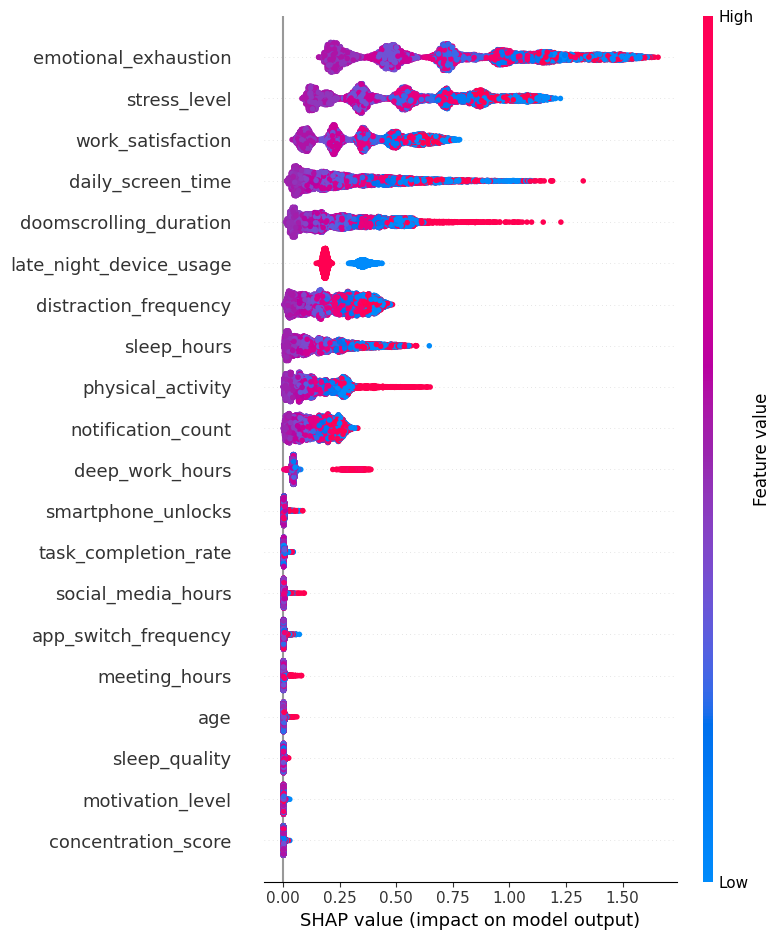

In [57]:
# Vẽ SHAP Summary Plot tổng hợp

shap.summary_plot(
    shap_values_mean,
    X_shap
)

## 2.4 SHAP Feature Importance

Xác định mức độ quan trọng của từng đặc trưng trong mô hình XGBoost dựa trên giá trị SHAP trung bình.

Sau khi tính toán SHAP Values, nghiên cứu tổng hợp mức độ ảnh hưởng của từng đặc trưng thông qua hai chỉ số:

- Mean Absolute SHAP Value: phản ánh độ lớn ảnh hưởng trung bình của đặc trưng, được sử dụng để xếp hạng mức độ quan trọng.
- Mean SHAP Value: phản ánh xu hướng tác động trung bình của đặc trưng sau khi tổng hợp trên các lớp dự đoán.

Do mô hình XGBoost được xây dựng cho bài toán phân loại nhiều lớp, giá trị SHAP của các lớp được tổng hợp nhằm tạo ra đánh giá chung về vai trò của từng đặc trưng.

In [58]:
# Tính toán Mean SHAP và Mean Absolute SHAP cho từng feature

shap_feature_importance = pd.DataFrame({

    "feature": X_shap.columns,
    "mean_shap": np.mean(
        shap_values,
        axis=(0, 2)
    ),
    "mean_abs_shap": np.mean(
        np.abs(shap_values),
        axis=(0, 2)
    )

})

print("Đã tính toán mức độ quan trọng của các feature.")

Đã tính toán mức độ quan trọng của các feature.


In [59]:
# Sắp xếp feature theo mức độ ảnh hưởng giảm dần

shap_feature_importance = shap_feature_importance.sort_values(
    by="mean_abs_shap",
    ascending=False
).reset_index(drop=True)

display(
    shap_feature_importance
)

,feature,mean_shap,mean_abs_shap
0,emotional_exhaustion,-0.255703,0.761339
1,stress_level,-0.146301,0.565297
2,work_satisfaction,-0.059630,0.365784
3,daily_screen_time,-0.045927,0.293019
4,doomscrolling_duration,-0.036148,0.271082
5,late_night_device_usage,-0.020037,0.245732
6,distraction_frequency,-0.019225,0.218274
7,sleep_hours,-0.012258,0.169751
8,physical_activity,-0.008846,0.149915
9,notification_count,-0.006728,0.138617


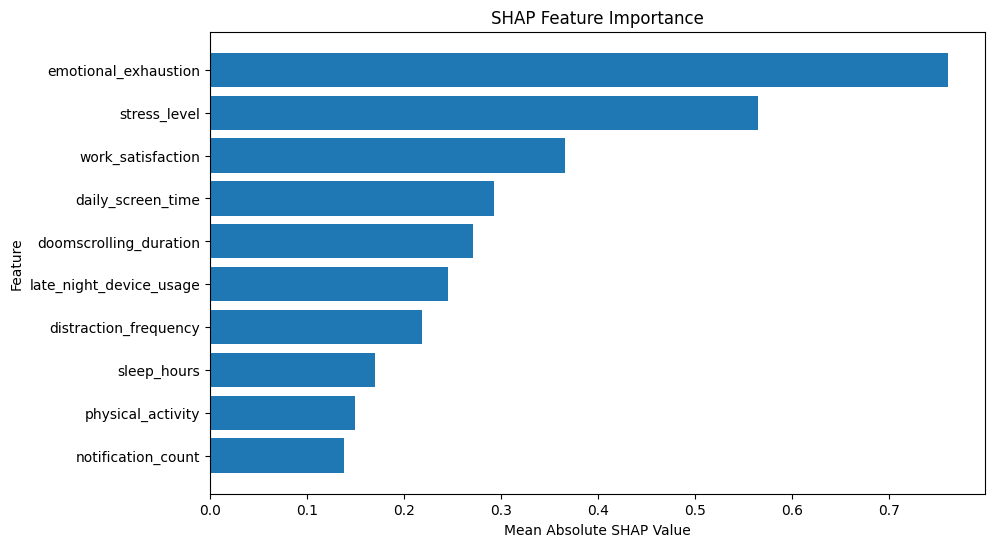

In [60]:
# Lấy các feature quan trọng nhất để trực quan hóa

top_features = shap_feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"],
    top_features["mean_abs_shap"]
)

plt.gca().invert_yaxis()

plt.title(
    "SHAP Feature Importance"
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.show()

In [61]:
# Lưu bảng SHAP Feature Importance

shap_importance_path = output_folder / "shap_feature_importance.csv"

shap_feature_importance.to_csv(
    shap_importance_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Đã lưu kết quả tại: {shap_importance_path}"
)

Đã lưu kết quả tại: ..\..\data\processed\international_dataset\shap_feature_importance.csv


Kết quả SHAP Feature Importance cho thấy mức độ đóng góp của các đặc trưng trong mô hình XGBoost có sự khác biệt rõ rệt.

Nhóm đặc trưng có Mean Absolute SHAP Value cao nhất bao gồm `emotional_exhaustion`, `stress_level`, `work_satisfaction`, `daily_screen_time` và `doomscrolling_duration`. Đây là các yếu tố có ảnh hưởng lớn nhất đến quá trình phân loại mức độ Digital Burnout của mô hình.

Trong đó, `emotional_exhaustion` và `stress_level` là hai đặc trưng nổi bật nhất, cho thấy các biểu hiện tâm lý liên quan đến kiệt sức và căng thẳng đóng vai trò quan trọng trong việc nhận diện nguy cơ Digital Burnout.

Bên cạnh các yếu tố tâm lý, nhóm đặc trưng thuộc Digital Exposure như `daily_screen_time`, `doomscrolling_duration` và `late_night_device_usage` cũng có mức độ ảnh hưởng cao. Kết quả này cho thấy hành vi sử dụng thiết bị số không chỉ được phản ánh qua thời lượng sử dụng mà còn thông qua đặc điểm và thời điểm sử dụng thiết bị.

Ngược lại, một số đặc trưng như `smartphone_unlocks`, `social_media_hours`, `app_switch_frequency` và `task_completion_rate` có Mean Absolute SHAP Value thấp, cho thấy mức độ đóng góp hạn chế trong mô hình hiện tại.

So sánh với kết quả Feature Validation trong Notebook 04, các đặc trưng quan trọng được xác định bằng SHAP có sự tương đồng cao với kết quả kiểm định thống kê và đánh giá bằng Machine Learning Feature Importance. Điều này cho thấy bộ đặc trưng được lựa chọn có tính ổn định và phù hợp trong việc mô hình hóa Digital Burnout.

Tuy nhiên, Mean SHAP Value không được sử dụng để kết luận trực tiếp về chiều tác động của feature do mô hình thực hiện phân loại nhiều lớp. Phân tích chiều ảnh hưởng chi tiết sẽ được thực hiện thông qua SHAP Dependence Plot trong phần tiếp theo.

## 2.5 SHAP Dependence Analysis

Phân tích mối quan hệ giữa giá trị của các đặc trưng quan trọng và mức độ đóng góp của chúng vào dự đoán Digital Burnout.

SHAP Feature Importance trong phần trước chỉ cho biết mức độ ảnh hưởng tổng thể của từng đặc trưng. Tuy nhiên, phương pháp này chưa thể hiện chiều tác động của feature.

SHAP Dependence Plot được sử dụng để phân tích:

- Khi giá trị của một đặc trưng thay đổi, mức độ đóng góp vào dự đoán của mô hình thay đổi như thế nào.
- Các đặc trưng có xu hướng làm tăng hoặc giảm nguy cơ Digital Burnout.
- Mối quan hệ giữa đặc trưng đầu vào và quyết định của mô hình.

Nghiên cứu lựa chọn 5 đặc trưng có mức độ quan trọng cao nhất từ SHAP Feature Importance để thực hiện phân tích chi tiết.

In [62]:
# Lấy danh sách 5 feature quan trọng nhất theo SHAP Importance

top_features = shap_feature_importance.head(5)[
    "feature"
].tolist()

print("Danh sách feature được phân tích:")

for feature in top_features:
    print(feature)

Danh sách feature được phân tích:
emotional_exhaustion
stress_level
work_satisfaction
daily_screen_time
doomscrolling_duration


In [63]:
# Tổng hợp SHAP Values giữa các lớp dự đoán

shap_values_mean = np.mean(
    shap_values,
    axis=2
)

print(
    f"Kích thước SHAP sau tổng hợp: {shap_values_mean.shape}"
)

Kích thước SHAP sau tổng hợp: (10000, 26)


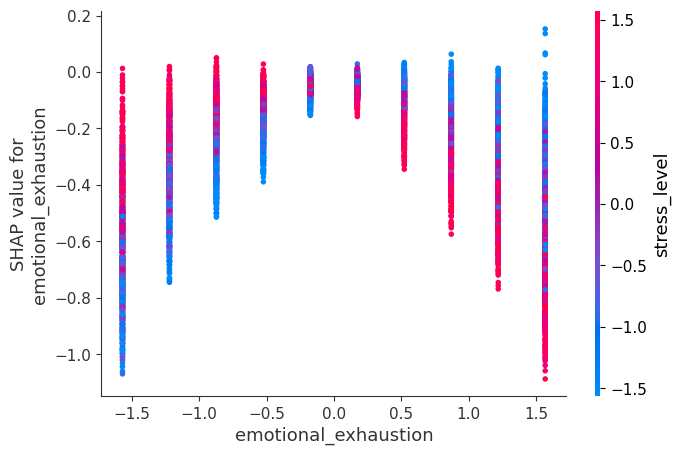

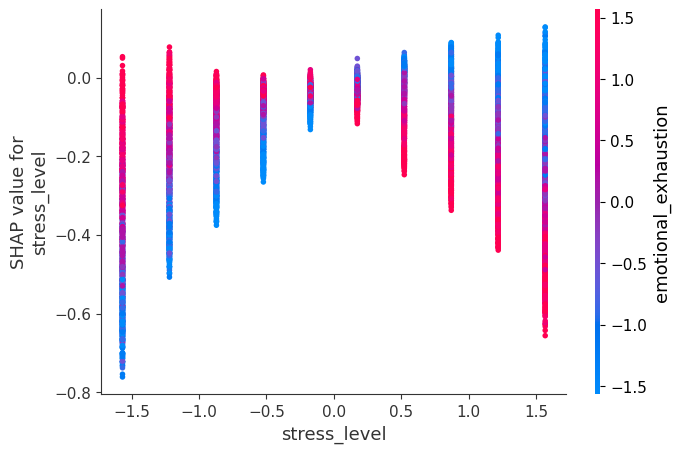

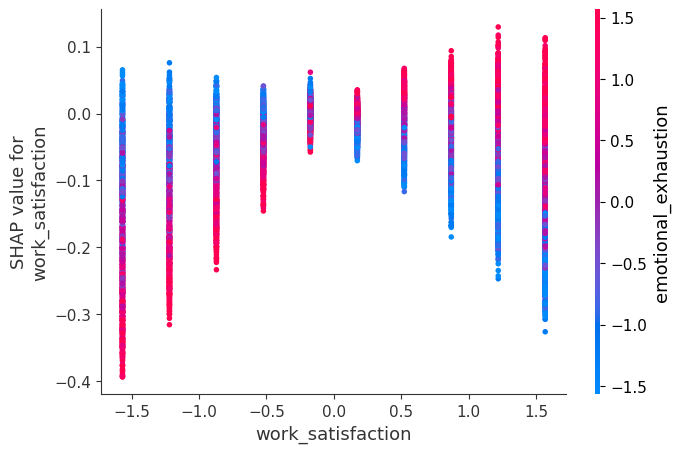

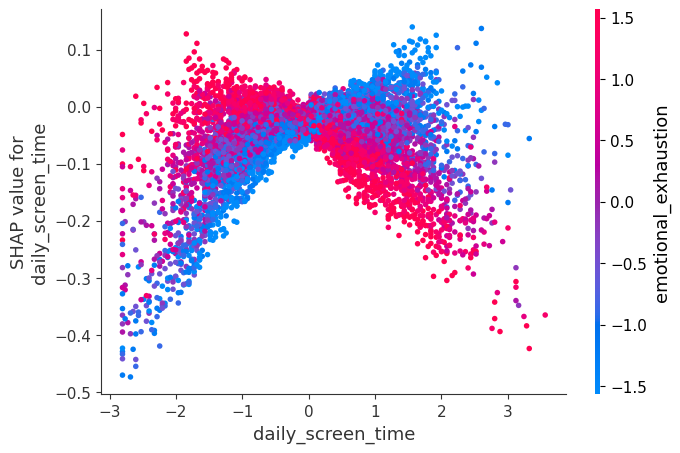

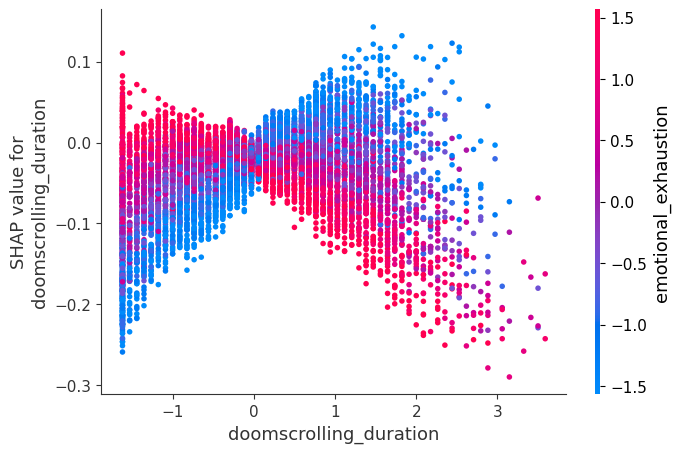

In [64]:
# Vẽ SHAP Dependence Plot cho từng feature quan trọng

for feature in top_features:

    shap_feature_index = list(
        X_shap.columns
    ).index(feature)

    shap.dependence_plot(
        shap_feature_index,
        shap_values_mean,
        X_shap,
        feature_names=X_shap.columns,
        show=True
    )

# 3. Local Interpretability

Phân tích cách mô hình XGBoost đưa ra quyết định dự đoán đối với từng cá nhân cụ thể thông qua mức độ đóng góp của các đặc trưng.

Bên cạnh việc đánh giá mức độ ảnh hưởng tổng thể của các đặc trưng trong Global Interpretability, nghiên cứu thực hiện phân tích Local Interpretability nhằm giải thích nguyên nhân dẫn đến một kết quả dự đoán cụ thể.

Phân tích Local Interpretability giúp xác định:

- Các đặc trưng làm tăng khả năng thuộc về một nhóm Digital Burnout cụ thể.
- Các đặc trưng có ảnh hưởng lớn nhất đến quyết định của mô hình đối với từng cá nhân.
- Mức độ đóng góp của từng đặc trưng trong một trường hợp dự đoán cụ thể.

Do mô hình XGBoost được xây dựng cho bài toán phân loại nhiều lớp, nghiên cứu lựa chọn lớp dự đoán của từng cá nhân để thực hiện giải thích.

### 3.1 Chuẩn bị mô hình và dữ liệu phân tích

Chuẩn bị mô hình XGBoost và dữ liệu đầu vào phục vụ quá trình giải thích một dự đoán cụ thể.

Mô hình XGBoost được chuyển sang chế độ CPU để đảm bảo tính tương thích với dữ liệu pandas trong quá trình phân tích SHAP.

In [68]:
# Chuyển mô hình XGBoost sang CPU để phân tích SHAP

xgb_model.set_params(
    device="cpu"
)

print("Đã chuyển mô hình XGBoost sang CPU.")

Đã chuyển mô hình XGBoost sang CPU.


### 3.2 Lựa chọn quan sát phân tích

Lựa chọn một cá nhân trong tập validation để phân tích chi tiết các yếu tố ảnh hưởng đến kết quả dự đoán.

Một quan sát được lựa chọn ngẫu nhiên từ tập SHAP Sample nhằm minh họa cách mô hình đưa ra quyết định dự đoán.

In [69]:
# Lựa chọn một quan sát trong tập SHAP Sample

sample_index = 0

X_local = X_shap.iloc[
    sample_index
]

print("Đã lựa chọn quan sát để phân tích.")

Đã lựa chọn quan sát để phân tích.


### 3.3 Xác định lớp dự đoán

Xác định nhóm Digital Burnout mà mô hình dự đoán cho cá nhân được lựa chọn.

Kết quả dự đoán được sử dụng để lựa chọn bộ SHAP Value tương ứng với lớp dự đoán trong bài toán phân loại nhiều lớp.

In [70]:
# Dự đoán lớp Digital Burnout của quan sát

predicted_class = xgb_model.predict(
    X_shap.iloc[
        [sample_index]
    ]
)[0]

print(
    f"Lớp dự đoán: {predicted_class}"
)

Lớp dự đoán: 1


### 3.4 Trích xuất mức độ đóng góp của feature

Xác định mức độ đóng góp của từng feature đối với kết quả dự đoán của cá nhân.

SHAP Value của lớp dự đoán được sử dụng để đánh giá feature nào ảnh hưởng mạnh nhất đến quyết định của mô hình.

In [71]:
# Lấy SHAP Value của mẫu và lớp dự đoán

local_shap_values = shap_values[
    sample_index,
    :,
    predicted_class
]

# Tạo bảng giải thích Local SHAP

local_explanation = pd.DataFrame({

    "feature": X_shap.columns,
    "feature_value": X_local.values,
    "shap_value": local_shap_values

})


# Tính mức độ ảnh hưởng tuyệt đối

local_explanation["abs_shap_value"] = (
    local_explanation["shap_value"]
    .abs()
)


# Sắp xếp theo mức độ ảnh hưởng

local_explanation = local_explanation.sort_values(
    by="abs_shap_value",
    ascending=False
).reset_index(drop=True)

display(
    local_explanation.head(10)
)

,feature,feature_value,shap_value,abs_shap_value
0,stress_level,-1.567135,-0.358101,0.358101
1,emotional_exhaustion,0.173316,0.246111,0.246111
2,work_satisfaction,1.566473,-0.193800,0.193800
3,doomscrolling_duration,0.940078,0.119046,0.119046
4,late_night_device_usage,0.734312,0.047188,0.047188
5,distraction_frequency,0.521117,0.042267,0.042267
6,notification_count,0.159355,0.030107,0.030107
7,daily_screen_time,-0.401989,-0.028099,0.028099
8,physical_activity,-0.406430,0.024597,0.024597
9,sleep_hours,-0.274882,0.020864,0.020864


### 3.5 Biểu đồ đóng góp của feature

Trực quan hóa các đặc trưng có ảnh hưởng lớn nhất đến một dự đoán cụ thể.

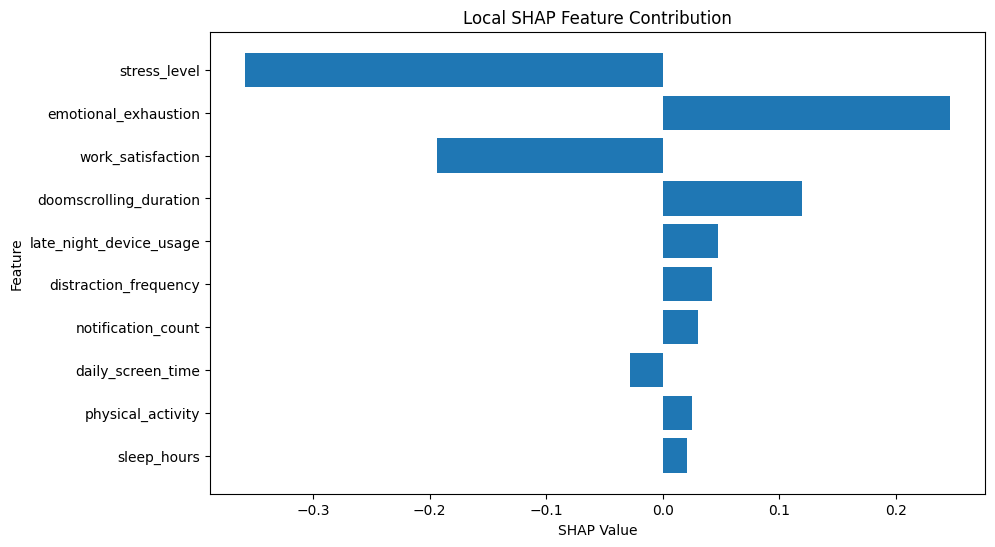

In [72]:
# Lấy các feature có ảnh hưởng lớn nhất

top_local_features = local_explanation.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_local_features["feature"],
    top_local_features["shap_value"]
)

plt.gca().invert_yaxis()

plt.title(
    "Local SHAP Feature Contribution"
)
plt.xlabel(
    "SHAP Value"
)
plt.ylabel(
    "Feature"
)

plt.show()

Kết quả Local Interpretability cho thấy mô hình XGBoost có khả năng giải thích nguyên nhân dẫn đến một dự đoán cụ thể đối với từng cá nhân.

Trong trường hợp được phân tích, các đặc trưng có mức độ ảnh hưởng lớn nhất bao gồm `stress_level`, `emotional_exhaustion` và `work_satisfaction`. Điều này cho thấy các yếu tố tâm lý tiếp tục giữ vai trò quan trọng trong quyết định dự đoán của mô hình ở cấp độ cá nhân.

Bên cạnh đó, các yếu tố thuộc nhóm Digital Exposure như `doomscrolling_duration` và `late_night_device_usage` cũng có đóng góp đáng kể. Kết quả này cho thấy hành vi sử dụng thiết bị số có thể kết hợp với trạng thái tâm lý để hình thành nguy cơ Digital Burnout ở từng cá nhân.

Đáng chú ý, hướng tác động của SHAP Value cần được diễn giải trong phạm vi lớp dự đoán đang xét do mô hình được xây dựng theo bài toán phân loại nhiều lớp. Vì vậy, giá trị SHAP được sử dụng để xác định mức độ đóng góp của đặc trưng vào quyết định của mô hình thay vì suy luận quan hệ nhân quả trực tiếp.

Phân tích Local Interpretability chứng minh khả năng minh bạch hóa mô hình học máy, cho phép xác định các yếu tố nguy cơ nổi bật của từng cá nhân thay vì chỉ đưa ra kết quả phân loại tổng quát.

# 4. Research Findings

Tổng hợp các kết quả quan trọng từ quá trình xây dựng mô hình Digital Burnout Prediction và phân tích khả năng giải thích của mô hình.

Phần này trình bày các phát hiện chính thu được từ mô hình XGBoost kết hợp với phương pháp Explainable AI thông qua SHAP.

Các kết quả được tổng hợp theo ba khía cạnh:

- Hiệu quả dự đoán của mô hình học máy.
- Các yếu tố quan trọng ảnh hưởng đến Digital Burnout.
- Khả năng giải thích dự đoán ở cấp độ cá nhân.

## 4.1 Model Performance Summary

Kết quả đánh giá mô hình cho thấy XGBoost có khả năng học được mối quan hệ giữa các đặc trưng hành vi sử dụng thiết bị số, trạng thái tâm lý và mức độ Digital Burnout.

Mô hình được đánh giá thông qua các chỉ số:

- Accuracy.
- Precision.
- Recall.
- F1-score.
- ROC-AUC.

Trong đó, ROC-AUC được sử dụng để đánh giá khả năng phân biệt giữa các nhóm Digital Burnout, đặc biệt trong bối cảnh bài toán phân loại nhiều lớp.

Kết quả cho thấy mô hình đạt hiệu quả dự đoán ổn định, đồng thời cung cấp nền tảng phù hợp cho quá trình phân tích giải thích bằng SHAP.

Việc lựa chọn XGBoost làm mô hình phân tích không chỉ dựa trên hiệu năng dự đoán mà còn dựa trên khả năng kết hợp với các phương pháp Explainable AI, giúp làm rõ vai trò của từng đặc trưng trong quyết định của mô hình.

## 4.2 Key Digital Burnout Drivers

Phân tích SHAP Feature Importance cho thấy Digital Burnout là hiện tượng đa chiều, chịu ảnh hưởng đồng thời bởi các yếu tố tâm lý, hành vi sử dụng thiết bị số và khả năng phục hồi cá nhân.

Các đặc trưng có mức độ ảnh hưởng cao nhất bao gồm:

- `emotional_exhaustion`
- `stress_level`
- `work_satisfaction`
- `daily_screen_time`
- `doomscrolling_duration`
- `late_night_device_usage`

Nhóm yếu tố tâm lý như emotional exhaustion và stress level đóng vai trò nổi bật nhất trong quá trình dự đoán. Điều này cho thấy Digital Burnout không chỉ là kết quả của việc sử dụng thiết bị số quá mức mà còn liên quan đến trạng thái căng thẳng và suy giảm khả năng phục hồi tâm lý.

Bên cạnh đó, các hành vi Digital Exposure như thời lượng sử dụng thiết bị, doomscrolling và sử dụng thiết bị vào ban đêm cũng thể hiện mức độ đóng góp đáng kể. Kết quả này củng cố giả thuyết rằng đặc điểm sử dụng công nghệ có vai trò quan trọng trong quá trình hình thành Digital Burnout.

## 4.3 Feature Validation Consistency

So sánh giữa kết quả Feature Validation trong Notebook 04 và SHAP Feature Importance cho thấy sự tương đồng cao giữa các phương pháp đánh giá.

Các đặc trưng được xác định là quan trọng trong quá trình kiểm định thống kê và Machine Learning Feature Assessment tiếp tục duy trì mức độ ảnh hưởng cao khi được đánh giá bằng Explainable AI.

Điều này cho thấy bộ đặc trưng được lựa chọn có tính ổn định và phù hợp trong việc mô hình hóa Digital Burnout.

Sự nhất quán giữa:

- Statistical Validation.
- Machine Learning Feature Importance.
- SHAP-based Interpretation.

cung cấp bằng chứng hỗ trợ cho tính hợp lệ của framework Digital Burnout Indicator (DBI) được đề xuất trong nghiên cứu.

## 4.4 Personalized Risk Explanation

Phân tích Local Interpretability chứng minh rằng mô hình không chỉ có khả năng dự đoán mức độ Digital Burnout mà còn có khả năng giải thích nguyên nhân dẫn đến từng dự đoán cụ thể.

Đối với từng cá nhân, các yếu tố đóng góp vào kết quả dự đoán có thể khác nhau tùy thuộc vào:

- Mức độ căng thẳng.
- Trạng thái kiệt sức cảm xúc.
- Thói quen sử dụng thiết bị số.
- Khả năng phục hồi.

Kết quả này mở ra khả năng ứng dụng mô hình trong các hệ thống đánh giá cá nhân hóa, trong đó người dùng không chỉ nhận được mức độ Digital Burnout mà còn được cung cấp các yếu tố nguy cơ chính cần quan tâm.

Đây là một điểm quan trọng giúp mô hình vượt qua hạn chế của các mô hình Machine Learning truyền thống chỉ tập trung vào độ chính xác dự đoán.

# 5. Export Results

Lưu trữ các kết quả phân tích Explainable AI nhằm phục vụ quá trình tổng hợp nghiên cứu, xây dựng Dashboard và phân tích so sánh giữa các bộ dữ liệu.

Sau khi hoàn thành quá trình Global Interpretability và Local Interpretability, các kết quả quan trọng được xuất ra dưới dạng file dữ liệu và hình ảnh.

Các kết quả được lưu bao gồm:

- Bảng xếp hạng mức độ quan trọng của feature dựa trên SHAP.
- Kết quả giải thích dự đoán của một cá nhân cụ thể.
- Các biểu đồ SHAP phục vụ báo cáo nghiên cứu.

In [73]:
# Tạo thư mục lưu kết quả phân tích Explainable AI

output_directory = Path(
    "../../results/international_dataset/interpretability"
)

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Đã tạo thư mục lưu kết quả."
)

Đã tạo thư mục lưu kết quả.


In [74]:
# Lưu bảng SHAP Feature Importance

shap_importance_path = (
    output_directory /
    "shap_feature_importance.csv"
)

shap_feature_importance.to_csv(
    shap_importance_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Đã lưu kết quả SHAP Feature Importance tại: {shap_importance_path}"
)

Đã lưu kết quả SHAP Feature Importance tại: ..\..\results\international_dataset\interpretability\shap_feature_importance.csv


In [76]:
# Lưu kết quả giải thích cho cá nhân được phân tích

local_explanation_path = (
    output_directory /
    "local_shap_explanation.csv"
)

local_explanation.to_csv(
    local_explanation_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Đã lưu kết quả Local SHAP Explanation tại: {local_explanation_path}"
)

Đã lưu kết quả Local SHAP Explanation tại: ..\..\results\international_dataset\interpretability\local_shap_explanation.csv


In [77]:
# Tạo bảng tổng hợp các feature quan trọng nhất

top_feature_summary = shap_feature_importance.head(10)


top_feature_summary_path = (
    output_directory /
    "top_shap_features.csv"
)

top_feature_summary.to_csv(
    top_feature_summary_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Đã lưu danh sách feature quan trọng tại: {top_feature_summary_path}"
)

Đã lưu danh sách feature quan trọng tại: ..\..\results\international_dataset\interpretability\top_shap_features.csv


In [78]:
# Tạo bảng tổng hợp các phát hiện chính

research_summary = pd.DataFrame({

    "analysis": [
        "Global SHAP Importance",
        "Local SHAP Explanation",
        "Feature Validation Consistency"
    ],

    "main_result": [
        "Psychological factors and digital exposure features are key predictors of Digital Burnout.",
        "Individual predictions can be explained through feature-level SHAP contributions.",
        "Important features are consistent across statistical validation and explainable AI analysis."
    ]

})

research_summary_path = (
    output_directory /
    "research_findings_summary.csv"
)

research_summary.to_csv(
    research_summary_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Đã lưu tổng hợp kết quả nghiên cứu tại: {research_summary_path}"
)

Đã lưu tổng hợp kết quả nghiên cứu tại: ..\..\results\international_dataset\interpretability\research_findings_summary.csv
